# Sales Prediction using Python
### CodeAlpha Data Science Internship — Task 4

**Objective:** Predict product sales based on advertising spend across different
platforms (TV, Radio, Newspaper), understand how changes in advertising budget
affect sales, and deliver actionable insights for marketing strategy.

**Dataset:** `Advertising.xlsx` — 200 records of advertising spend (in thousands of
dollars) on TV, Radio and Newspaper, and the resulting product Sales (in thousands
of units).


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

%matplotlib inline


## 2. Load the Data

In [2]:
df = pd.read_excel("data/Advertising.xlsx")
print("Shape:", df.shape)
df.head()


Shape: (200, 5)


,Column1,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Column1    200 non-null    int64  
 1   TV         200 non-null    float64
 2   Radio      200 non-null    float64
 3   Newspaper  200 non-null    float64
 4   Sales      200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
df.isnull().sum()


Column1      0
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## 3. Data Cleaning

- `Column1` is just a row index carried over from the CSV export — we drop it.
- No missing values or duplicates are present.
- All spend and sales figures are numeric and ready for analysis.


In [5]:
df_model = df.drop(columns=['Column1']) if 'Column1' in df.columns else df.copy()
print("Duplicate rows:", df_model.duplicated().sum())
df_model = df_model.drop_duplicates()
df_model.describe()


Duplicate rows: 0


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## 4. Exploratory Data Analysis

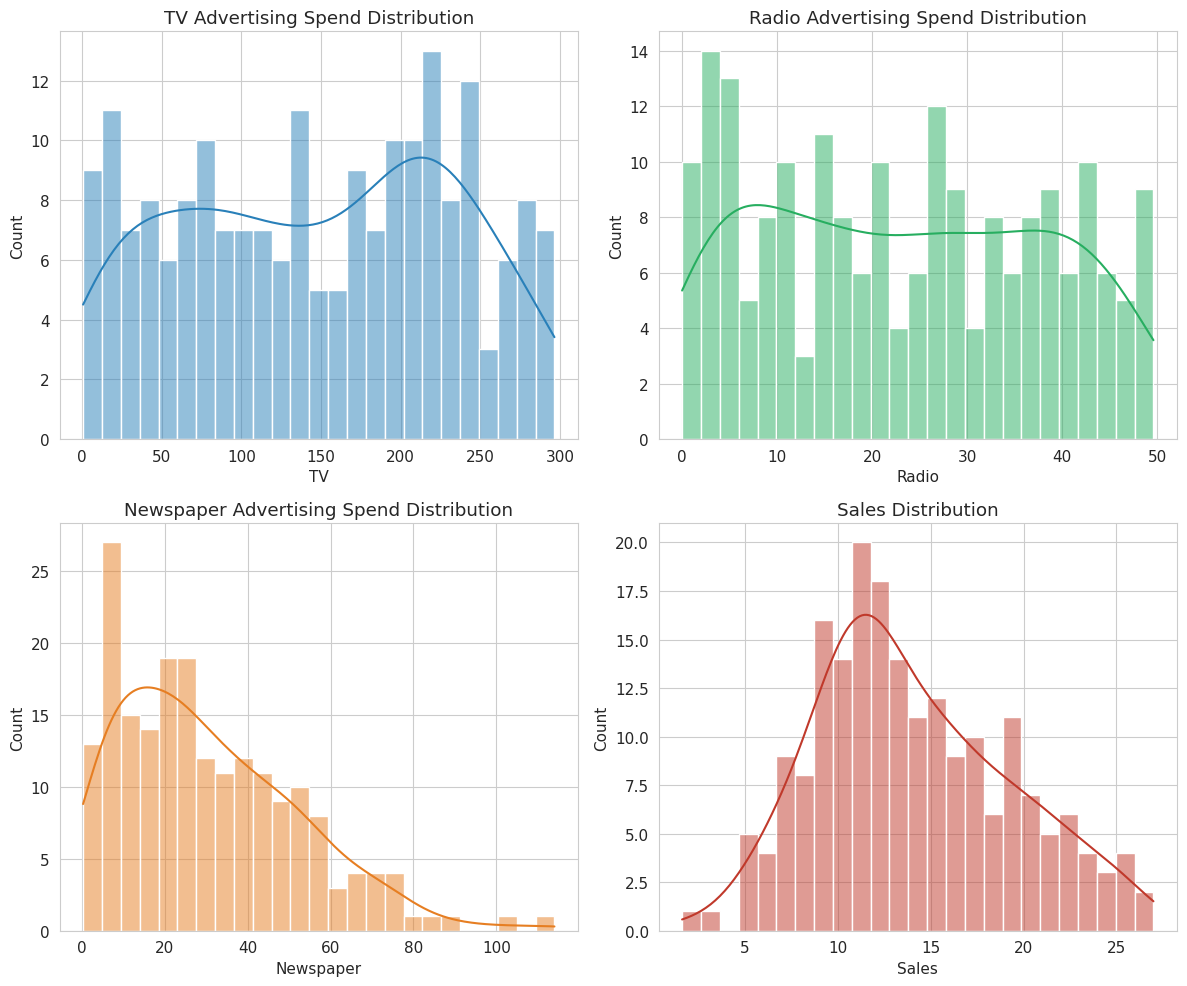

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
sns.histplot(df_model['TV'], bins=25, kde=True, ax=axes[0,0], color='#2980b9')
axes[0,0].set_title('TV Advertising Spend Distribution')
sns.histplot(df_model['Radio'], bins=25, kde=True, ax=axes[0,1], color='#27ae60')
axes[0,1].set_title('Radio Advertising Spend Distribution')
sns.histplot(df_model['Newspaper'], bins=25, kde=True, ax=axes[1,0], color='#e67e22')
axes[1,0].set_title('Newspaper Advertising Spend Distribution')
sns.histplot(df_model['Sales'], bins=25, kde=True, ax=axes[1,1], color='#c0392b')
axes[1,1].set_title('Sales Distribution')
plt.tight_layout()
plt.savefig('images/01_distributions.png', dpi=150)
plt.show()


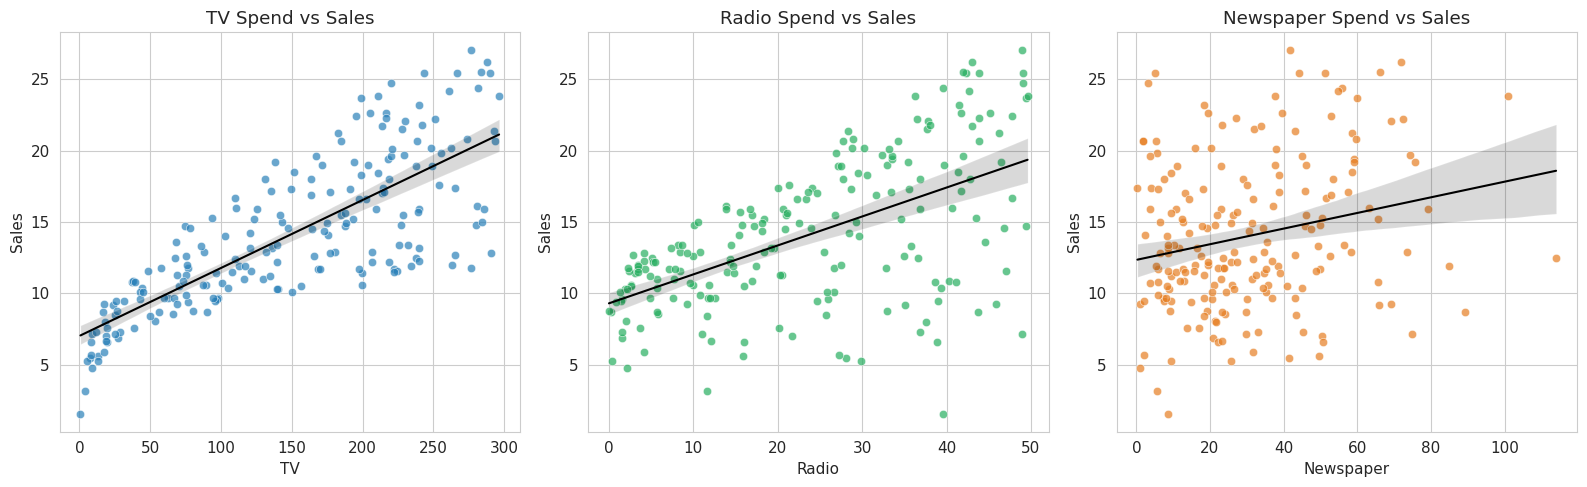

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, col, color in zip(axes, ['TV','Radio','Newspaper'], ['#2980b9','#27ae60','#e67e22']):
    sns.scatterplot(data=df_model, x=col, y='Sales', ax=ax, color=color, alpha=0.7)
    sns.regplot(data=df_model, x=col, y='Sales', ax=ax, scatter=False, color='black', line_kws={'linewidth':1.5})
    ax.set_title(f'{col} Spend vs Sales')
plt.tight_layout()
plt.savefig('images/02_spend_vs_sales.png', dpi=150)
plt.show()


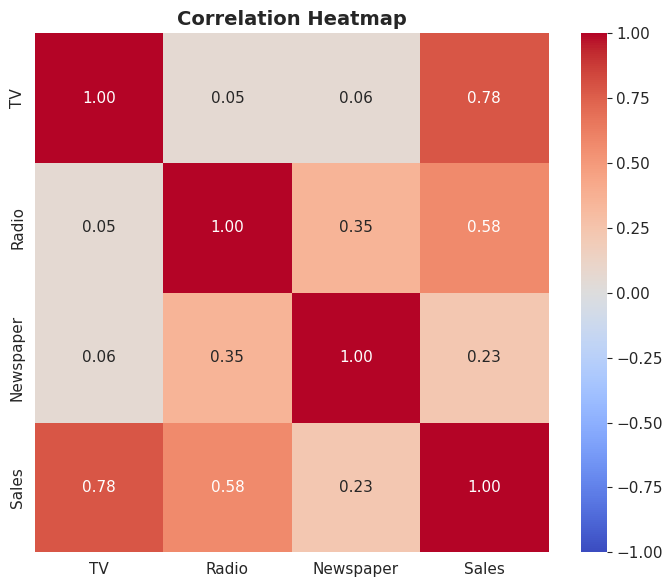

Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64

In [8]:
plt.figure(figsize=(7,6))
corr = df_model.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/03_correlation_heatmap.png', dpi=150)
plt.show()

corr['Sales'].sort_values(ascending=False)


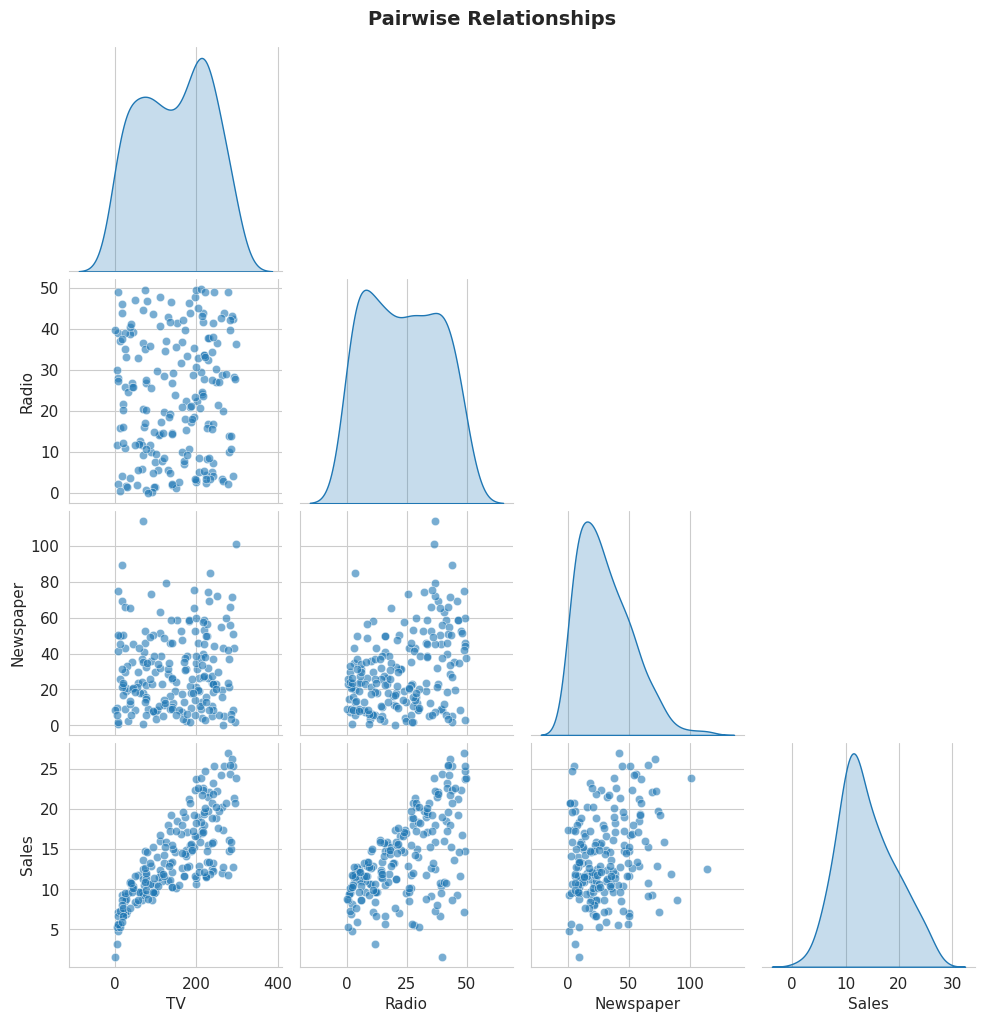

In [9]:
sns.pairplot(df_model, diag_kind='kde', corner=True, plot_kws={'alpha':0.6})
plt.suptitle('Pairwise Relationships', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('images/04_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Advertising Budget Mix

We look at how the average advertising budget is split across TV, Radio and
Newspaper, since a channel's total spend share is a useful business context for
interpreting model coefficients later.


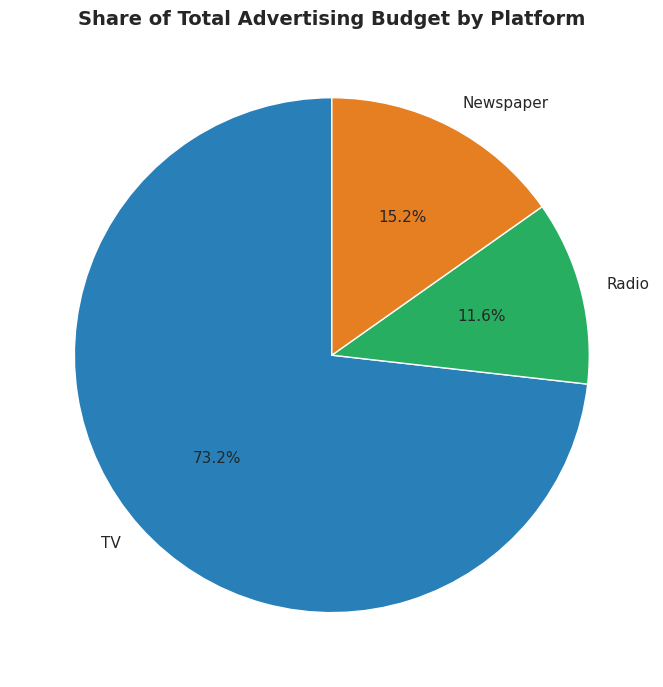

In [10]:
budget_share = df_model[['TV','Radio','Newspaper']].sum()
plt.figure(figsize=(7,7))
plt.pie(budget_share, labels=budget_share.index, autopct='%1.1f%%', colors=['#2980b9','#27ae60','#e67e22'], startangle=90)
plt.title('Share of Total Advertising Budget by Platform', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/05_budget_share.png', dpi=150)
plt.show()


## 6. Preprocessing for Modeling

**Features:** `TV`, `Radio`, `Newspaper` advertising spend
**Target:** `Sales`

All features are already numeric, so no encoding is needed. We scale features for
the linear models and keep an 80/20 train-test split.


In [11]:
features = ['TV', 'Radio', 'Newspaper']
target = 'Sales'

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (160, 3)  Test shape: (40, 3)


## 7. Model Training

We train and compare four models:
1. **Linear Regression** — baseline, directly interpretable coefficients
2. **Ridge Regression** — regularized linear model
3. **Decision Tree Regressor**
4. **Random Forest Regressor** — ensemble model


In [12]:
models = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge Regression': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Decision Tree': Pipeline([('model', DecisionTreeRegressor(random_state=42, max_depth=4))]),
    'Random Forest': Pipeline([('model', RandomForestRegressor(random_state=42, n_estimators=200, max_depth=6))])
}

results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')

    results[name] = {'pipeline': pipe, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
                      'CV_R2_mean': cv_scores.mean(), 'CV_R2_std': cv_scores.std()}

    print(f"{name}")
    print(f"  MAE:  {mae:.3f}  |  RMSE: {rmse:.3f}  |  R2: {r2:.3f}  |  5-Fold CV R2: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    print()


Linear Regression
  MAE:  1.461  |  RMSE: 1.782  |  R2: 0.899  |  5-Fold CV R2: 0.887 (+/- 0.040)

Ridge Regression
  MAE:  1.464  |  RMSE: 1.787  |  R2: 0.899  |  5-Fold CV R2: 0.887 (+/- 0.041)

Decision Tree
  MAE:  1.369  |  RMSE: 1.824  |  R2: 0.895  |  5-Fold CV R2: 0.910 (+/- 0.031)



Random Forest
  MAE:  0.646  |  RMSE: 0.787  |  R2: 0.980  |  5-Fold CV R2: 0.974 (+/- 0.009)



## 8. Model Comparison

In [13]:
comparison_df = pd.DataFrame({
    name: {'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R2': r['R2'], 'CV_R2_mean': r['CV_R2_mean']}
    for name, r in results.items()
}).T
comparison_df


,MAE,RMSE,R2,CV_R2_mean
Linear Regression,1.460757,1.781600,0.899438,0.887106
Ridge Regression,1.464301,1.787220,0.898803,0.887165
Decision Tree,1.368822,1.823790,0.894619,0.909692
Random Forest,0.645973,0.787012,0.980377,0.974331


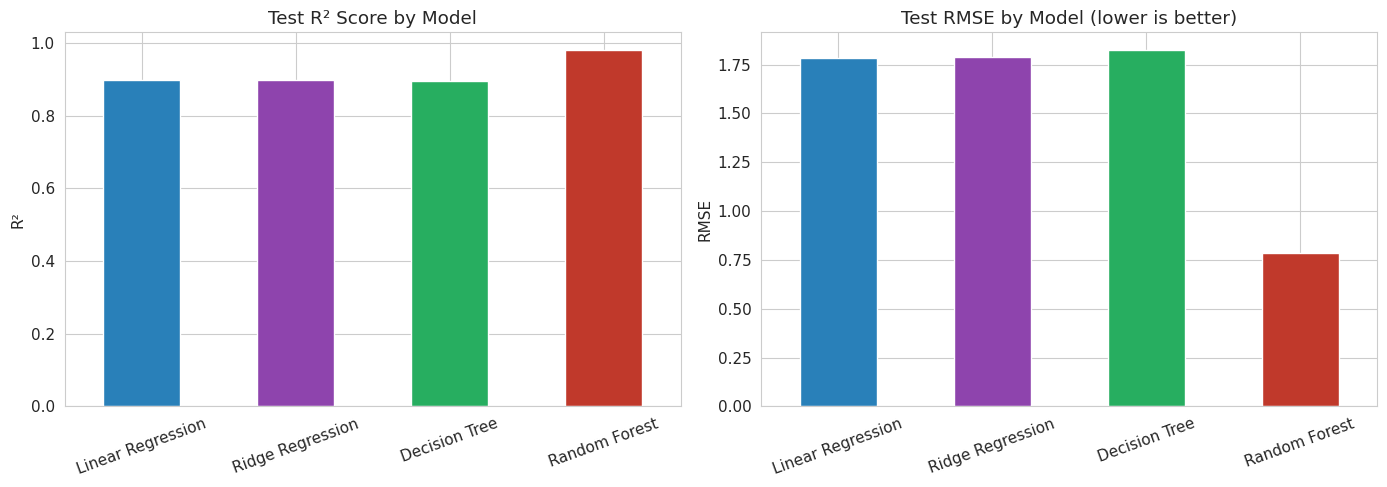

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
comparison_df['R2'].plot(kind='bar', ax=axes[0], color=['#2980b9','#8e44ad','#27ae60','#c0392b'])
axes[0].set_title('Test R² Score by Model')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=20)

comparison_df['RMSE'].plot(kind='bar', ax=axes[1], color=['#2980b9','#8e44ad','#27ae60','#c0392b'])
axes[1].set_title('Test RMSE by Model (lower is better)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('images/06_model_comparison.png', dpi=150)
plt.show()


In [15]:
best_model_name = comparison_df['R2'].idxmax()
best_pipeline = results[best_model_name]['pipeline']
print(f"Best performing model: {best_model_name} (Test R2 = {comparison_df.loc[best_model_name, 'R2']:.3f})")


Best performing model: Random Forest (Test R2 = 0.980)


## 9. Predicted vs Actual Sales (Best Model)

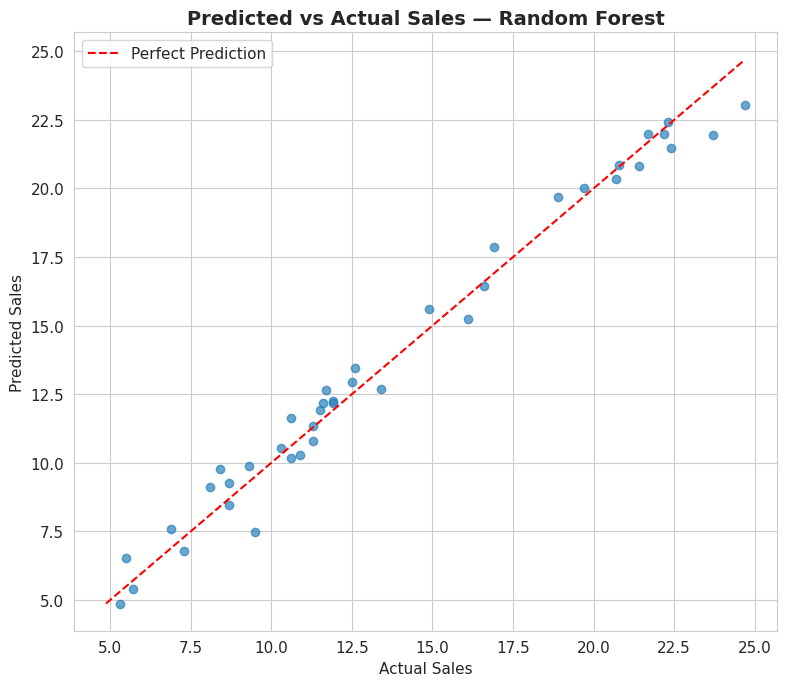

In [16]:
preds_best = best_pipeline.predict(X_test)

plt.figure(figsize=(8,7))
plt.scatter(y_test, preds_best, alpha=0.7, color='#2980b9')
lims = [min(y_test.min(), preds_best.min()), max(y_test.max(), preds_best.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(f'Predicted vs Actual Sales — {best_model_name}', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('images/07_predicted_vs_actual.png', dpi=150)
plt.show()


## 10. Understanding the Impact of Each Advertising Channel

For the linear model, coefficients tell us the expected change in sales per unit
increase in spend on each channel (after scaling, so magnitudes are comparable).
For the Random Forest, feature importance tells us which channel the model relies
on most for its predictions.


/tmp/ipykernel_637/1582438095.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef_series.values, y=coef_series.index, palette='crest')


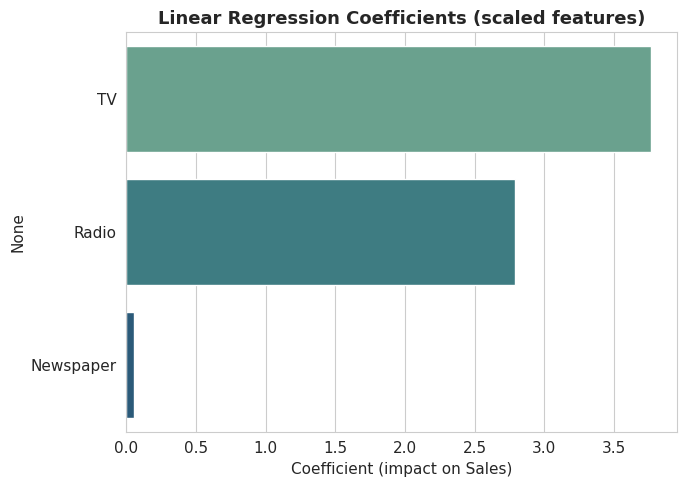

TV           3.764196
Radio        2.792307
Newspaper    0.055976
dtype: float64

In [17]:
lin_pipe = results['Linear Regression']['pipeline']
lin_model = lin_pipe.named_steps['model']
coef_series = pd.Series(lin_model.coef_, index=features).sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=coef_series.values, y=coef_series.index, palette='crest')
plt.title('Linear Regression Coefficients (scaled features)', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient (impact on Sales)')
plt.tight_layout()
plt.savefig('images/08_linear_coefficients.png', dpi=150)
plt.show()

coef_series


/tmp/ipykernel_637/1224486151.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_series.values, y=importance_series.index, palette='mako')


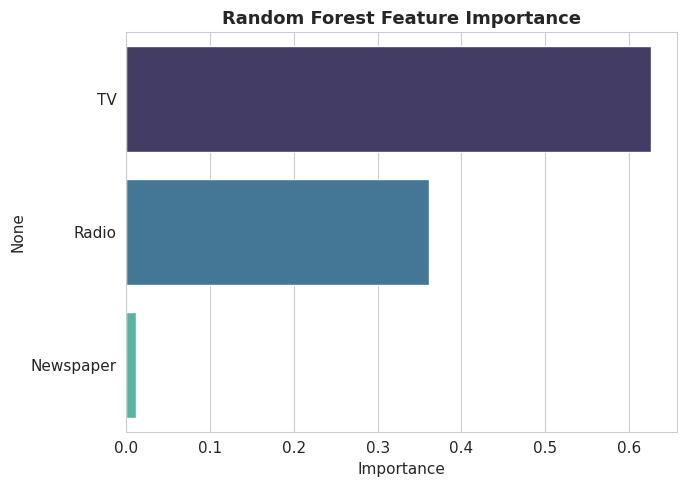

TV           0.626153
Radio        0.361870
Newspaper    0.011977
dtype: float64

In [18]:
rf_pipe = results['Random Forest']['pipeline']
rf_model = rf_pipe.named_steps['model']
importance_series = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=importance_series.values, y=importance_series.index, palette='mako')
plt.title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('images/09_rf_feature_importance.png', dpi=150)
plt.show()

importance_series


## 11. What-If Scenario: Impact of Increasing Advertising Spend

Using the best model, we simulate how Sales would change if we scaled up spend on
each channel independently, holding the others at their average levels — a
practical way to explore "what should we invest more in?".


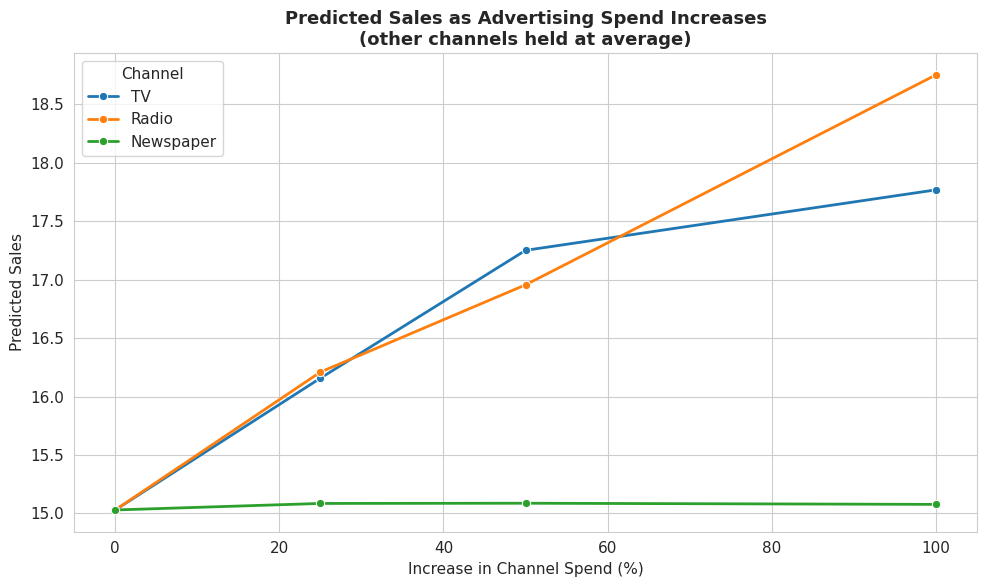

Channel,Newspaper,Radio,TV
Spend_Increase_%,,,
0,15.029171,15.029171,15.029171
25,15.084990,16.208935,16.156891
50,15.086787,16.955628,17.250701
100,15.076940,18.751782,17.768104


In [19]:
avg_spend = X.mean()
scenarios = []
for channel in features:
    for pct_increase in [0, 25, 50, 100]:
        row = avg_spend.copy()
        row[channel] = avg_spend[channel] * (1 + pct_increase/100)
        pred_sales = best_pipeline.predict(pd.DataFrame([row]))[0]
        scenarios.append({'Channel': channel, 'Spend_Increase_%': pct_increase, 'Predicted_Sales': pred_sales})

scenario_df = pd.DataFrame(scenarios)

plt.figure(figsize=(10,6))
sns.lineplot(data=scenario_df, x='Spend_Increase_%', y='Predicted_Sales', hue='Channel', marker='o', linewidth=2)
plt.title('Predicted Sales as Advertising Spend Increases\n(other channels held at average)', fontsize=13, fontweight='bold')
plt.xlabel('Increase in Channel Spend (%)')
plt.ylabel('Predicted Sales')
plt.tight_layout()
plt.savefig('images/10_whatif_scenarios.png', dpi=150)
plt.show()

scenario_df.pivot(index='Spend_Increase_%', columns='Channel', values='Predicted_Sales')


## 12. Predicting Sales for a New Advertising Budget

In [20]:
new_budget = pd.DataFrame([{'TV': 200, 'Radio': 40, 'Newspaper': 20}])
predicted_sales = best_pipeline.predict(new_budget)[0]
print(f"Predicted Sales for TV=200k, Radio=40k, Newspaper=20k budget: {predicted_sales:.2f} (thousand units)")
new_budget


Predicted Sales for TV=200k, Radio=40k, Newspaper=20k budget: 20.11 (thousand units)


,TV,Radio,Newspaper
0,200,40,20


## 13. Key Insights & Marketing Recommendations

1. **TV advertising has the strongest relationship with sales**, showing the
   highest correlation and largest coefficient/feature importance among the three
   channels.
2. **Radio advertising also has a meaningful positive effect** on sales, though
   smaller than TV.
3. **Newspaper advertising shows the weakest relationship with sales** — its
   correlation with sales is low, and both the linear model coefficient and the
   Random Forest importance rank it last. Newspaper spend also doesn't add much
   incremental predictive power once TV and Radio are accounted for.
4. **Diminishing but still positive returns**: the what-if simulation shows sales
   increases as spend increases on TV and Radio, though the rate of increase can
   flatten at higher spend levels for some channels.
5. **Budget reallocation opportunity**: Given Newspaper's weak relationship with
   sales, businesses may get better returns by reallocating some Newspaper budget
   toward TV and Radio, though this should be validated with real-world A/B
   testing before making large budget shifts.

## 14. Conclusion

This project analyzed 200 advertising campaigns and built regression models to
predict sales from TV, Radio, and Newspaper spend. Linear Regression already
performs very well on this dataset (advertising-sales relationships are close to
linear), and all models agree that **TV is the dominant driver of sales**, Radio
has a secondary but real effect, and **Newspaper contributes the least**. These
insights can guide marketing budget allocation toward the channels with the
strongest demonstrated impact on sales.
